# Urban Accessibility Analysis: Network-Distance Connectivity in Kenya's Major Cities

This notebook measures how well connected residents of Kenya's major cities are to everyday essential services: education, health, retail, and social life using network distance rather than straight line. The analysis focused on computing accessibilty across different every day needs rather than a single "walkability" score.

**Tools:** OSMnx (road network + POI extraction from OpenStreetMap), `city2graph` (network-distance Waxman graph construction), GeoPandas, contextily, matplotlib

In [1]:
# importing Libraries
import geopandas as gpd
import osmnx as ox
import folium
import contextily as ctx
import matplotlib.pyplot as plt
from shapely.geometry import box
import city2graph as c2g
from matplotlib.lines import Line2D

In [2]:
# defining our cities
cities = ['Mombasa, Kenya', 'Nakuru, Kenya', 'Kisumu, Kenya']

### Defining the points of interest (POIs)

Four categories of everyday essential services are pulled from OpenStreetMap tags:

| Category | OSM tags |
|---|---|
| **Education** | `amenity`: school, university |
| **Daily needs** | `shop`: supermarket, convenience |
| **Social life** | `amenity`: restaurant, cafe |
| **Health services** | `amenity`: hospital, clinic, pharmacy |

In [3]:
# defining our working scope
poi_queries = {
    'education': {'amenity': ['school', 'university']},
    'daily_needs': {'shop': ['supermarket', 'convenience']},
    'social_life': {'amenity': ['restaurant']},
    'health_services': {'amenity': ['hospital', 'clinic', 'pharmacy']}
}


In [4]:
# defining radius
radius = 2000

In [5]:
# check to ensure each city has a poi feature
poi_counts = {}
ox.settings.requests_timeout = 180
for city_name in cities:    
    print(f"{city_name}")
    poi_counts[city_name] = {}

    for label, query in poi_queries.items():
        try:
            poi = ox.features_from_place(city_name, query).to_crs(32737)
            poi = poi[poi.geometry.type == "Point"]
            count = len(poi)
           
            poi_counts[city_name][label] = count
            print(f"  {label}: {count}")

        except Exception as e:
            poi_counts[city_name][label] = 0
            print(f"  {label}: failed → {e}")
    

Mombasa, Kenya
  education: 56
  daily_needs: 35
  social_life: 86
  health_services: 32
Nakuru, Kenya
  education: 19
  daily_needs: 13
  social_life: 33
  health_services: 12
Kisumu, Kenya
  education: 94
  daily_needs: 21
  social_life: 38
  health_services: 113


### Building the network-distance connectivity graph

This is the core methodological step. `city2graph.waxman_graph()` builds a graph connecting POIs within a 2km distance with the distance being measured along the road network. A POI is only linked to another if it's genuinely reachable within that distance by road.

Parameters used:
- `r0 = 2000` (2km network-distance radius)
- `beta = 0.5`: controls how sharply connection probability falls off with distance in the Waxman model
- `network_gdf`: the actual road network pulled above, so distances respect real streets

The result is one connectivity graph per service category, per city.


In [6]:
ox.settings.requests_timeout = 360
for city_name in cities:
    print(f'\n Processing {city_name}')

    # Convert city boundary to gdf and project
    admin = ox.geocode_to_gdf(city_name).to_crs(32737)

    # get the path network
    G = ox.graph_from_place(city_name, network_type='drive')
    segments_gdf = ox.graph_to_gdfs(G)[1].to_crs(32737)

    # getting the POIs
    poi_layers = {}
    for label, query in poi_queries.items():
        poi = ox.features_from_place(city_name, query).to_crs(32737)
        poi_layers[label] = poi[poi.geometry.type == 'Point']
        print(f'{label}: {len(poi_layers[label])} points')

    # Build Waxman Graphs
    wax_graphs = {}
    for label, pois in poi_layers.items():
        if len(pois) > 1:
            nodes, edges = c2g.waxman_graph(
                pois,
                distance_metric = 'network',
                r0 = radius,
                beta = 0.5,
                network_gdf = segments_gdf
            )
            wax_graphs[label] = edges
            print(f'{label}: {len(poi_layers[label])} points, {len(edges)} edges')
        else:
            wax_graphs[label] = gpd.GeoDataFrame()


 Processing Mombasa, Kenya
education: 57 points
daily_needs: 35 points
social_life: 86 points
health_services: 32 points
education: 57 points, 71 edges
daily_needs: 35 points, 45 edges
social_life: 86 points, 335 edges
health_services: 32 points, 31 edges

 Processing Nakuru, Kenya
education: 19 points
daily_needs: 13 points
social_life: 33 points
health_services: 12 points
education: 19 points, 20 edges
daily_needs: 13 points, 11 edges
social_life: 33 points, 55 edges
health_services: 12 points, 13 edges

 Processing Kisumu, Kenya
education: 94 points
daily_needs: 21 points
social_life: 38 points
health_services: 113 points
education: 94 points, 500 edges
daily_needs: 21 points, 25 edges
social_life: 38 points, 93 edges
health_services: 113 points, 782 edges


### Visualization

In [12]:
layer_colors = {
    'education': '#00e5ff',
    'daily_needs': '#ffea00',
    'social_life': '#ff4081',
    'health_services': '#76ff03' 
}

In [18]:
def plot_city_connectivity(city_name, admin, poi_layers, wax_graphs, radius):
    fig, ax = plt.subplots(1, 1, figsize=(8,8))
    fig.patch.set_facecolor('black')
    
    admin.boundary.plot(ax=ax, color='white', linewidth=2.0, alpha=0.6, zorder=5)

    for label in ['daily_needs', 'health_services', 'education', 'social_life']:
        edges = wax_graphs.get(label)
        if edges is None or edges.empty:
            continue
        color = layer_colors[label]
        for _, row in edges.iterrows():
            x, y = row.geometry.xy
            ax.plot(x, y, color=color, linewidth=2.0, alpha=0.05, zorder=6)
            ax.plot(x, y, color=color, linewidth=0.6, alpha=0.3, zorder=7)
    
    # ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatterNoLabels, crs=3857, zoom=11, attribution=False)
    
    ax.set_axis_off()

    all_bounds = [gdf.total_bounds for gdf in wax_graphs.values() if not gdf.empty]

    minx = min(b[0] for b in all_bounds)
    miny = min(b[1] for b in all_bounds)
    maxx = max(b[2] for b in all_bounds)
    maxy = max(b[3] for b in all_bounds)

    buffer_x = (maxx - minx) * 0.05
    buffer_y = (maxy - miny) * 0.05

    zoom_minx = minx - buffer_x
    zoom_maxx = maxx + buffer_x
    zoom_miny = miny - buffer_y
    zoom_maxy = maxy + buffer_y

    ax.set_xlim(zoom_minx, zoom_maxx)
    ax.set_ylim(zoom_miny, zoom_maxy)

    outer_box = box(
        zoom_minx - buffer_x, zoom_miny - buffer_y,
        zoom_maxx + buffer_x, zoom_maxy + buffer_y
    )

    city_shape = admin.geometry.union_all()
    mask_geom = outer_box.difference(city_shape)
    gpd.GeoSeries([mask_geom], crs=admin.crs).plot(
        ax=ax, color='black', zorder=4
    )

    # Legend
    legend_elements = [Line2D([0], [0], color=color, lw=3, label=label.replace("_"," ").title()) for label, color in layer_colors.items()]

    legend = ax.legend(
        handles=legend_elements,
        loc='lower left',
        bbox_to_anchor=(0.02, -0.02),
        frameon=True,
        framealpha=1,
        facecolor='black',
        edgecolor='black',
        fontsize=9,
        labelcolor='white',
        title= "  " + city_name.split(",")[0],
        title_fontproperties={'weight':'bold', 'size':15}
    )
    legend.get_title().set_color('white')
    
    plt.tight_layout()
    plt.show()


Generating graph for Mombasa, Kenya


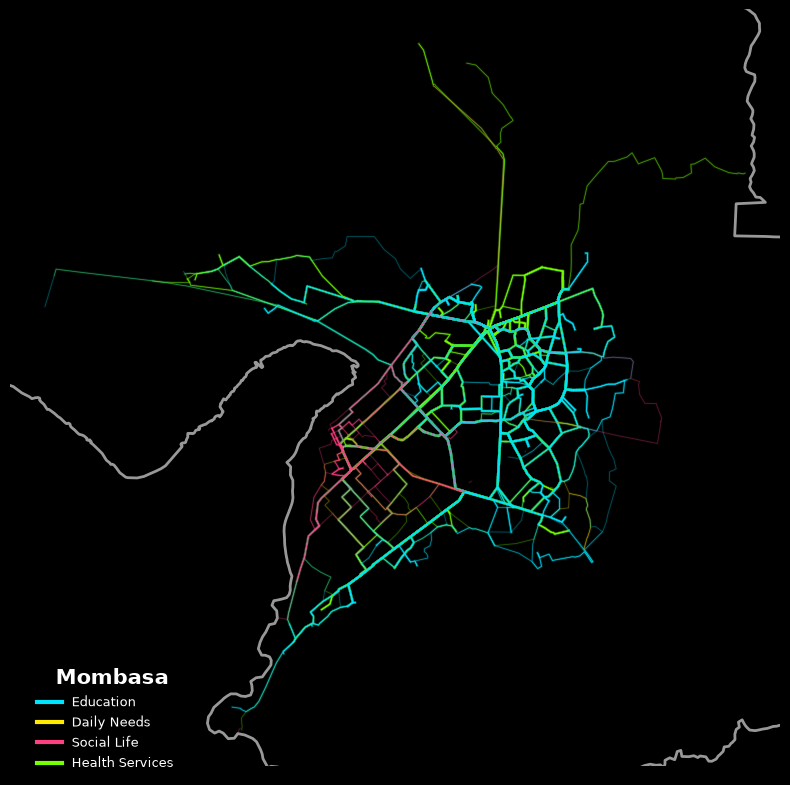

Generating graph for Nakuru, Kenya


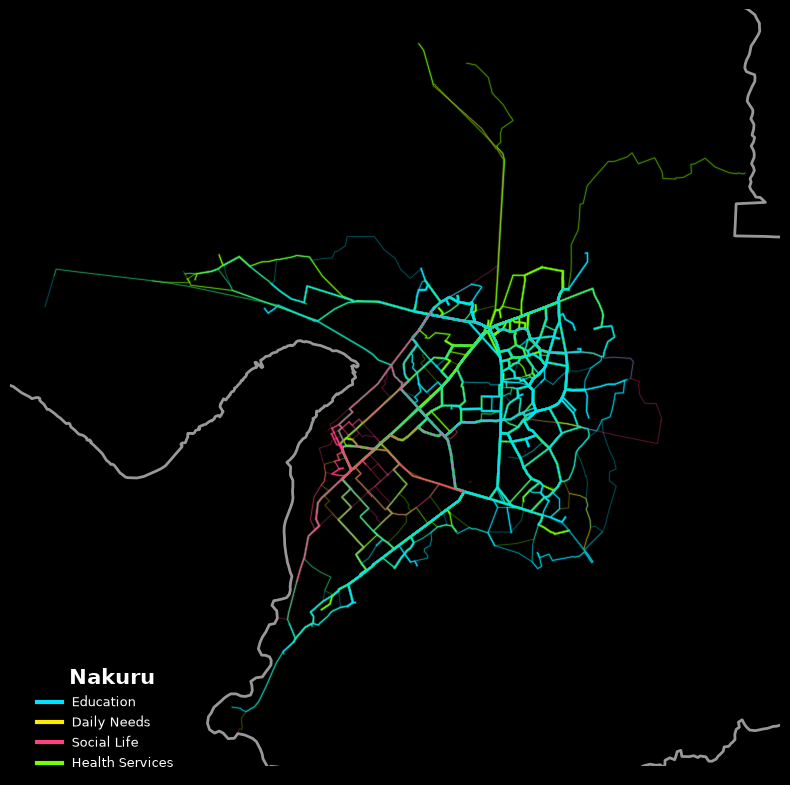

Generating graph for Kisumu, Kenya


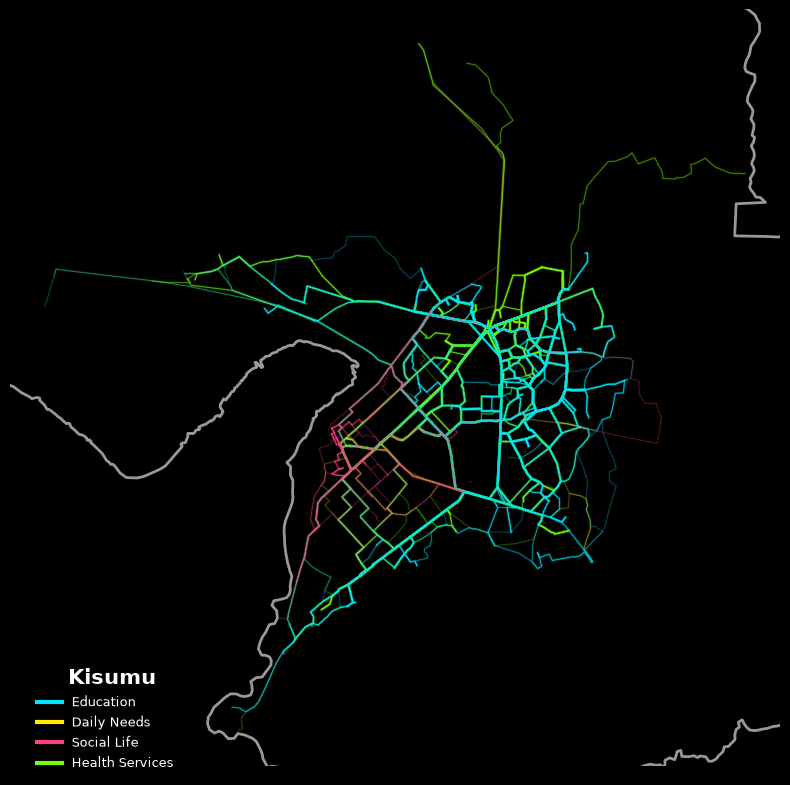

In [19]:
for city_name in cities:
    print(f"Generating graph for {city_name}")

    plot_city_connectivity(
        city_name,
        admin,
        poi_layers,
        wax_graphs,
        radius
    )